# Study B Phase 1: Relative Noise Impact (AL-Only)

This notebook performs a **relative** frequency-domain OF-weighted impact study.

It reports:

- relative information proxy
- relative sensitivity proxy
- relative improvement/degradation versus baseline

It does **not** yet define final detector resolution from time-domain OF-amplitude spread.


## Section 1 — Import and Reuse Preprocessed AL Objects

AL noise interpretation is considered validated from Study A.

`signal.dat` physical interpretation may still be incomplete.
Therefore this notebook computes **relative OF-weighted sensitivity proxies**, not final absolute resolution.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

base_dir_candidates = [Path("Al2O3_Al_athermal"), Path("wk6/Al2O3_Al_athermal")]
base_dir = next((p for p in base_dir_candidates if p.exists()), None)
if base_dir is None:
    raise FileNotFoundError("Could not locate wk6/Al2O3_Al_athermal from current working directory.")

signal_path = base_dir / "signal.dat"
noise_paths = {
    "total": base_dir / "total_noise.dat",
    "squid": base_dir / "SQUID_noise.dat",
    "johnson": base_dir / "Johnson_noise.dat",
    "td": base_dir / "TD_noise.dat",
    "er": base_dir / "Er_noise.dat",
}

signal_data = np.loadtxt(signal_path)
noise_data = {k: np.loadtxt(v) for k, v in noise_paths.items()}

for key, arr in noise_data.items():
    if arr.ndim != 2 or arr.shape[1] < 2:
        raise ValueError(f"Noise file '{key}' must be 2-column [freq, ASD].")

al_freq = noise_data["total"][:, 0]
for key, arr in noise_data.items():
    if arr.shape[0] != al_freq.shape[0] or not np.allclose(arr[:, 0], al_freq):
        raise ValueError(f"Noise file '{key}' is not on the common AL frequency grid.")

# Validated Study A convention: AL noise second columns are ASD; PSD is ASD^2.
asd_total = noise_data["total"][:, 1]
asd_squid = noise_data["squid"][:, 1]
asd_johnson = noise_data["johnson"][:, 1]
asd_td = noise_data["td"][:, 1]
asd_er = noise_data["er"][:, 1]

psd_total = asd_total**2
psd_squid = asd_squid**2
psd_johnson = asd_johnson**2
psd_td = asd_td**2
psd_er = asd_er**2

al_psd_components = {
    "SQUID": psd_squid,
    "Johnson": psd_johnson,
    "TD": psd_td,
    "Er": psd_er,
}

print("Loaded AL-only inputs for Study B Phase 1:")
print(f"- signal.dat shape: {signal_data.shape}")
print(f"- AL frequency bins: {al_freq.size}, range=[{al_freq[0]:.6g}, {al_freq[-1]:.6g}] Hz")


Loaded AL-only inputs for Study B Phase 1:
- signal.dat shape: (16384, 2)
- AL frequency bins: 16384, range=[1, 3e+07] Hz


## Section 2 — Inspect and Define Usable Signal Representation

At this stage, `signal.dat` is used only as a **relative spectral template** unless independent calibration metadata is available.


signal.dat structural checks:
- ndim=2, shape=(16384, 2)
- finite axis=True
- finite values=True
- any negative values=False
- all positive values=True
signal axis: n=16384, min=1, max=3e+07, monotonic_non_decreasing=True, monotonic_strict=True
signal axis step stats: min=0.00105144, median=5.75595, max=31510.1
- exact signal axis match to AL grid: True
- overlap band available: True
- overlap [Hz]: [1, 3e+07]


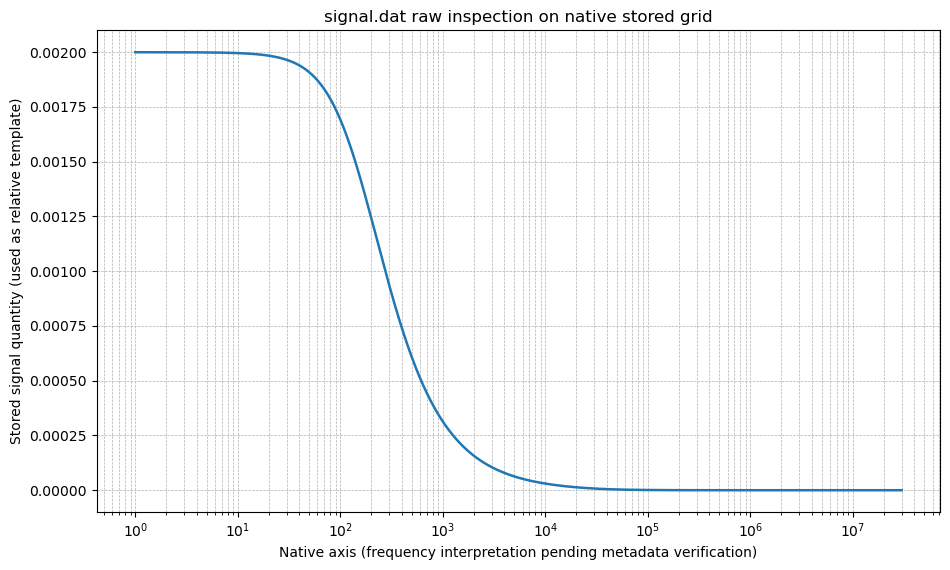

Prepared S_rel on overlap grid with 16384 bins.


In [9]:
def summarize_axis(name, x):
    dx = np.diff(x)
    print(
        f"{name}: n={x.size}, min={np.nanmin(x):.6g}, max={np.nanmax(x):.6g}, "
        f"monotonic_non_decreasing={bool(np.all(dx >= 0))}, monotonic_strict={bool(np.all(dx > 0))}"
    )
    if dx.size:
        print(f"{name} step stats: min={np.nanmin(dx):.6g}, median={np.nanmedian(dx):.6g}, max={np.nanmax(dx):.6g}")

if signal_data.ndim == 2 and signal_data.shape[1] >= 2:
    signal_axis = signal_data[:, 0]
    signal_value_raw = signal_data[:, 1]
    signal_axis_available = True
elif signal_data.ndim == 1:
    signal_axis = np.arange(signal_data.size, dtype=float)
    signal_value_raw = signal_data
    signal_axis_available = False
else:
    raise ValueError("Unsupported signal.dat shape; expected 1D or 2D with >=2 columns.")

print("signal.dat structural checks:")
print(f"- ndim={signal_data.ndim}, shape={signal_data.shape}")
print(f"- finite axis={bool(np.all(np.isfinite(signal_axis)))}")
print(f"- finite values={bool(np.all(np.isfinite(signal_value_raw)))}")
print(f"- any negative values={bool(np.any(signal_value_raw < 0))}")
print(f"- all positive values={bool(np.all(signal_value_raw > 0))}")
summarize_axis("signal axis", signal_axis)

exact_grid_match = (
    signal_axis_available and signal_axis.shape == al_freq.shape and np.allclose(signal_axis, al_freq)
)
print(f"- exact signal axis match to AL grid: {exact_grid_match}")

if signal_axis_available:
    overlap_min = max(float(np.nanmin(signal_axis)), float(np.nanmin(al_freq)))
    overlap_max = min(float(np.nanmax(signal_axis)), float(np.nanmax(al_freq)))
else:
    overlap_min = np.nan
    overlap_max = np.nan

overlap_valid = np.isfinite(overlap_min) and np.isfinite(overlap_max) and overlap_max > overlap_min
print(f"- overlap band available: {overlap_valid}")
if overlap_valid:
    print(f"- overlap [Hz]: [{overlap_min:.6g}, {overlap_max:.6g}]")

plt.figure(figsize=(9.6, 5.8))
valid = np.isfinite(signal_axis) & np.isfinite(signal_value_raw)
if np.all(signal_axis[valid] > 0):
    plt.semilogx(signal_axis[valid], signal_value_raw[valid], linewidth=1.8)
else:
    plt.plot(signal_axis[valid], signal_value_raw[valid], linewidth=1.8)
plt.title("signal.dat raw inspection on native stored grid")
plt.xlabel("Native axis (frequency interpretation pending metadata verification)")
plt.ylabel("Stored signal quantity (used as relative template)")
plt.grid(True, which="both", linestyle="--", linewidth=0.5)
plt.tight_layout()
plt.show()

if not signal_axis_available:
    raise RuntimeError(
        "signal.dat does not provide an explicit axis; cannot align to AL frequency grid for OF-weighted relative analysis."
    )

# Build a relative template on AL grid over overlap only.
overlap_mask_al = (al_freq >= overlap_min) & (al_freq <= overlap_max)
if np.count_nonzero(overlap_mask_al) < 2:
    raise RuntimeError("Insufficient overlap between signal axis and AL frequency grid.")

if exact_grid_match:
    signal_on_al_overlap = signal_value_raw[overlap_mask_al]
    freq_overlap = al_freq[overlap_mask_al]
else:
    freq_overlap = al_freq[overlap_mask_al]
    signal_on_al_overlap = np.interp(freq_overlap, signal_axis, signal_value_raw, left=np.nan, right=np.nan)

S_rel = signal_on_al_overlap.copy()
print(f"Prepared S_rel on overlap grid with {S_rel.size} bins.")


## Section 3 — Build the Baseline OF Weighting Proxy

Define on overlap AL band:

\[
W(f) = rac{|S_{rel}(f)|^2}{P_{tot}(f)}
\]

Use robust masking (finite, positive frequency, finite signal, finite positive PSD).


In [10]:
def trapz_integral(x, y):
    return float(np.trapz(y, x))

psd_total_overlap = psd_total[(al_freq >= overlap_min) & (al_freq <= overlap_max)]

valid_base = (
    (freq_overlap > 0)
    & np.isfinite(freq_overlap)
    & np.isfinite(S_rel)
    & np.isfinite(psd_total_overlap)
    & (psd_total_overlap > 0)
)

freq_use = freq_overlap[valid_base]
S_use = S_rel[valid_base]
P_use = psd_total_overlap[valid_base]

if freq_use.size < 2:
    raise RuntimeError("Not enough valid bins for baseline OF-weighted proxy.")

W_base = (np.abs(S_use) ** 2) / P_use
I_base = trapz_integral(freq_use, W_base)

if not np.isfinite(I_base) or I_base <= 0:
    raise RuntimeError("Baseline information proxy I_base is non-positive or invalid.")

eta_rel_base = 1.0  # relative sensitivity proxy normalized to baseline

print("Baseline OF-weighting proxy diagnostics:")
print(f"- valid frequency interval [Hz]: [{freq_use[0]:.6g}, {freq_use[-1]:.6g}]")
print(f"- valid bin count: {freq_use.size}")
print(f"- I_base = ∫W(f)df = {I_base:.6g}")
print(f"- eta_rel_base (normalized) = {eta_rel_base:.6g}")


Baseline OF-weighting proxy diagnostics:
- valid frequency interval [Hz]: [1, 3e+07]
- valid bin count: 16384
- I_base = ∫W(f)df = 0.00551349
- eta_rel_base (normalized) = 1


## Section 4 — Baseline Signal-Band Diagnostics


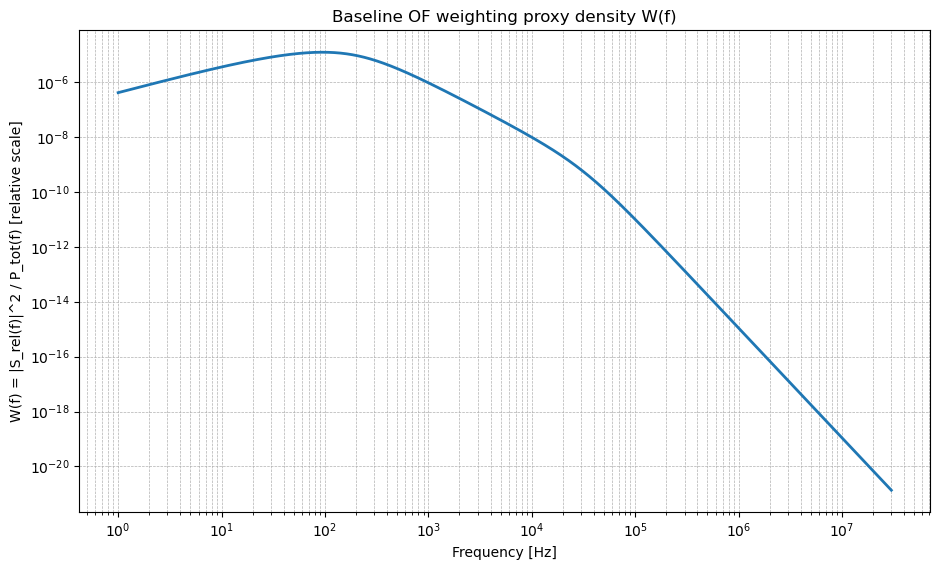

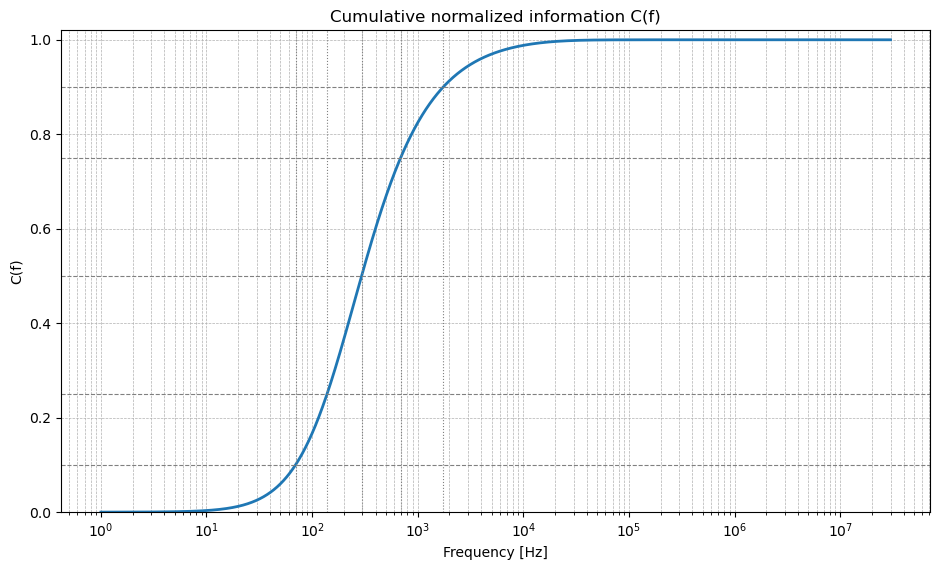

Landmark frequencies from cumulative information:
 cumulative_information_level  frequency_hz
                         0.10     69.674374
                         0.25    138.506644
                         0.50    294.194703
                         0.75    688.537190
                         0.90   1744.366230


,cumulative_information_level,frequency_hz
0,0.10,69.674374
1,0.25,138.506644
2,0.50,294.194703
3,0.75,688.537190
4,0.90,1744.366230


In [11]:
def cumulative_trapz_normalized(x, y):
    dx = np.diff(x)
    y_mid = 0.5 * (y[1:] + y[:-1])
    c = np.concatenate([[0.0], np.cumsum(dx * y_mid)])
    total = c[-1]
    if total <= 0 or not np.isfinite(total):
        return np.full_like(c, np.nan)
    return c / total

C_base = cumulative_trapz_normalized(freq_use, W_base)

landmark_levels = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
landmark_freqs = np.interp(landmark_levels, C_base, freq_use)
landmark_df = pd.DataFrame(
    {
        "cumulative_information_level": landmark_levels,
        "frequency_hz": landmark_freqs,
    }
)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.loglog(freq_use, W_base, linewidth=2.0)
ax.set_title("Baseline OF weighting proxy density W(f)")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("W(f) = |S_rel(f)|^2 / P_tot(f) [relative scale]")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.semilogx(freq_use, C_base, linewidth=2.0)
for lvl, f in zip(landmark_levels, landmark_freqs):
    ax.axhline(lvl, linestyle="--", linewidth=0.8, color="gray")
    ax.axvline(f, linestyle=":", linewidth=0.8, color="gray")
ax.set_title("Cumulative normalized information C(f)")
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("C(f)")
ax.set_ylim(0, 1.02)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
fig.tight_layout()
plt.show()

print("Landmark frequencies from cumulative information:")
print(landmark_df.to_string(index=False))
display(landmark_df)


## Section 5 — Leave-One-Out Study B Analysis

For each component, rebuild modified total PSD from remaining components and recompute relative metrics.


In [12]:
component_psd_overlap = {
    "SQUID": psd_squid[(al_freq >= overlap_min) & (al_freq <= overlap_max)][valid_base],
    "Johnson": psd_johnson[(al_freq >= overlap_min) & (al_freq <= overlap_max)][valid_base],
    "TD": psd_td[(al_freq >= overlap_min) & (al_freq <= overlap_max)][valid_base],
    "Er": psd_er[(al_freq >= overlap_min) & (al_freq <= overlap_max)][valid_base],
}

all_labels = list(component_psd_overlap.keys())

def compute_info_for_psd(P_mod, freq, S):
    valid = np.isfinite(P_mod) & (P_mod > 0) & np.isfinite(freq) & (freq > 0) & np.isfinite(S)
    if np.count_nonzero(valid) < 2:
        return np.nan, 0
    W = (np.abs(S[valid]) ** 2) / P_mod[valid]
    return trapz_integral(freq[valid], W), int(np.count_nonzero(valid))

loo_rows = []
for remove_label in all_labels:
    kept = [k for k in all_labels if k != remove_label]
    P_no = np.zeros_like(freq_use)
    for k in kept:
        P_no = P_no + component_psd_overlap[k]

    I_no, n_valid = compute_info_for_psd(P_no, freq_use, S_use)
    info_ratio = I_no / I_base if np.isfinite(I_no) and I_no > 0 else np.nan
    eta_rel = np.sqrt(I_base / I_no) if np.isfinite(I_no) and I_no > 0 else np.nan
    improvement_vs_baseline = (1.0 - eta_rel) if np.isfinite(eta_rel) else np.nan

    loo_rows.append(
        {
            "scenario": f"without {remove_label}",
            "information_proxy": I_no,
            "relative_information": info_ratio,
            "relative_sensitivity_proxy": eta_rel,
            "improvement_vs_baseline": improvement_vs_baseline,
            "valid_bins": n_valid,
        }
    )

loo_df = pd.DataFrame(loo_rows)
print("Leave-one-out relative impact table:")
print(loo_df.to_string(index=False))
display(loo_df)


Leave-one-out relative impact table:
       scenario  information_proxy  relative_information  relative_sensitivity_proxy  improvement_vs_baseline  valid_bins
  without SQUID           0.058836             10.671264                    0.306120                 0.693880       16384
without Johnson           0.005632              1.021495                    0.989423                 0.010577       16384
     without TD           0.006104              1.107046                    0.950424                 0.049576       16384
     without Er           0.005650              1.024725                    0.987862                 0.012138       16384


,scenario,information_proxy,relative_information,relative_sensitivity_proxy,improvement_vs_baseline,valid_bins
0,without SQUID,0.058836,10.671264,0.306120,0.693880,16384
1,without Johnson,0.005632,1.021495,0.989423,0.010577,16384
2,without TD,0.006104,1.107046,0.950424,0.049576,16384
3,without Er,0.005650,1.024725,0.987862,0.012138,16384


## Section 6 — Scale-Down Study B Analysis

For each component \(i\) and \(lpha \in \{0.8, 0.5, 0.2\}\):

\[
P_{tot}^{(i,lpha)}(f) = P_{tot}(f) - P_i(f) + lpha P_i(f)
\]

Then recompute relative metrics versus baseline.


Scale-down relative impact table:
            scenario component  scale_factor  information_proxy  relative_information  relative_sensitivity_proxy  improvement_vs_baseline  valid_bins
  scale SQUID by 0.8     SQUID           0.8           0.006666              1.208946                    0.909487                 0.090513       16384
  scale SQUID by 0.5     SQUID           0.5           0.009735              1.765634                    0.752575                 0.247425       16384
  scale SQUID by 0.2     SQUID           0.2           0.018417              3.340387                    0.547144                 0.452856       16384
scale Johnson by 0.8   Johnson           0.8           0.005537              1.004217                    0.997898                 0.002102       16384
scale Johnson by 0.5   Johnson           0.5           0.005572              1.010619                    0.994733                 0.005267       16384
scale Johnson by 0.2   Johnson           0.2           0.005

,scenario,component,scale_factor,information_proxy,relative_information,relative_sensitivity_proxy,improvement_vs_baseline,valid_bins
0,scale SQUID by 0.8,SQUID,0.8,0.006666,1.208946,0.909487,0.090513,16384
1,scale SQUID by 0.5,SQUID,0.5,0.009735,1.765634,0.752575,0.247425,16384
2,scale SQUID by 0.2,SQUID,0.2,0.018417,3.340387,0.547144,0.452856,16384
3,scale Johnson by 0.8,Johnson,0.8,0.005537,1.004217,0.997898,0.002102,16384
4,scale Johnson by 0.5,Johnson,0.5,0.005572,1.010619,0.994733,0.005267,16384
5,scale Johnson by 0.2,Johnson,0.2,0.005608,1.017113,0.991552,0.008448,16384
6,scale TD by 0.8,TD,0.8,0.005618,1.018937,0.990664,0.009336,16384
7,scale TD by 0.5,TD,0.5,0.005786,1.049465,0.976149,0.023851,16384
8,scale TD by 0.2,TD,0.2,0.005971,1.082901,0.960961,0.039039,16384
9,scale Er by 0.8,Er,0.8,0.005540,1.004819,0.997599,0.002401,16384


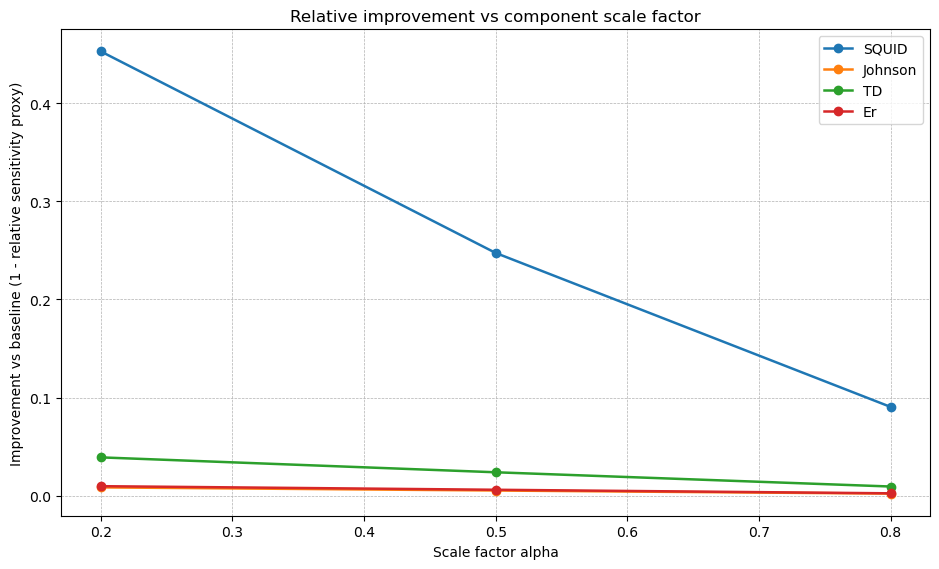

In [13]:
scale_factors = [0.8, 0.5, 0.2]
scale_rows = []

P_components = component_psd_overlap
P_sum_all = P_components["SQUID"] + P_components["Johnson"] + P_components["TD"] + P_components["Er"]

for comp in all_labels:
    Pi = P_components[comp]
    P_without = P_sum_all - Pi
    for alpha in scale_factors:
        P_mod = P_without + alpha * Pi
        I_mod, n_valid = compute_info_for_psd(P_mod, freq_use, S_use)
        info_ratio = I_mod / I_base if np.isfinite(I_mod) and I_mod > 0 else np.nan
        eta_rel = np.sqrt(I_base / I_mod) if np.isfinite(I_mod) and I_mod > 0 else np.nan
        improvement_vs_baseline = (1.0 - eta_rel) if np.isfinite(eta_rel) else np.nan
        scale_rows.append(
            {
                "scenario": f"scale {comp} by {alpha}",
                "component": comp,
                "scale_factor": alpha,
                "information_proxy": I_mod,
                "relative_information": info_ratio,
                "relative_sensitivity_proxy": eta_rel,
                "improvement_vs_baseline": improvement_vs_baseline,
                "valid_bins": n_valid,
            }
        )

scale_df = pd.DataFrame(scale_rows)
print("Scale-down relative impact table:")
print(scale_df.to_string(index=False))
display(scale_df)

fig, ax = plt.subplots(figsize=(9.5, 5.8))
for comp in all_labels:
    sub = scale_df[scale_df["component"] == comp].sort_values("scale_factor", ascending=False)
    ax.plot(
        sub["scale_factor"],
        sub["improvement_vs_baseline"],
        marker="o",
        linewidth=1.8,
        label=comp,
    )
ax.set_title("Relative improvement vs component scale factor")
ax.set_xlabel("Scale factor alpha")
ax.set_ylabel("Improvement vs baseline (1 - relative sensitivity proxy)")
ax.grid(True, linestyle="--", linewidth=0.5)
ax.legend()
fig.tight_layout()
plt.show()


## Section 7 — Ranking and Interpretation


In [14]:
summary_rows = []
summary_rows.append(
    {
        "scenario": "baseline",
        "information_proxy": I_base,
        "relative_sensitivity_proxy": 1.0,
        "improvement_vs_baseline": 0.0,
        "interpretation": "reference scenario",
    }
)

for _, row in loo_df.iterrows():
    imp = row["improvement_vs_baseline"]
    if np.isfinite(imp) and imp > 0:
        interp = "removal improves relative sensitivity proxy"
    elif np.isfinite(imp) and imp < 0:
        interp = "removal degrades relative sensitivity proxy"
    else:
        interp = "insufficient valid bins or undefined"

    summary_rows.append(
        {
            "scenario": row["scenario"],
            "information_proxy": row["information_proxy"],
            "relative_sensitivity_proxy": row["relative_sensitivity_proxy"],
            "improvement_vs_baseline": row["improvement_vs_baseline"],
            "interpretation": interp,
        }
    )

for _, row in scale_df.iterrows():
    imp = row["improvement_vs_baseline"]
    if np.isfinite(imp) and imp > 0:
        interp = "scaledown improves relative sensitivity proxy"
    elif np.isfinite(imp) and imp < 0:
        interp = "scaledown degrades relative sensitivity proxy"
    else:
        interp = "insufficient valid bins or undefined"

    summary_rows.append(
        {
            "scenario": row["scenario"],
            "information_proxy": row["information_proxy"],
            "relative_sensitivity_proxy": row["relative_sensitivity_proxy"],
            "improvement_vs_baseline": row["improvement_vs_baseline"],
            "interpretation": interp,
        }
    )

study_b_phase1_summary_df = pd.DataFrame(summary_rows)
print("Study B Phase 1 summary table:")
print(study_b_phase1_summary_df.to_string(index=False))
display(study_b_phase1_summary_df)

# Concise ranking summary
best_removal = loo_df.sort_values("improvement_vs_baseline", ascending=False).iloc[0]
best_realistic = scale_df.sort_values("improvement_vs_baseline", ascending=False).iloc[0]

frac_use = {
    k: np.nanmedian(component_psd_overlap[k] / P_use)
    for k in all_labels
}
dominant_asd_source_band = max(frac_use.items(), key=lambda kv: kv[1])[0]
dominant_of_bottleneck = str(best_removal["scenario"]).replace("without ", "")

text_lines = [
    "### Study B Phase 1 Relative Ranking Summary",
    f"- Largest leave-one-out improvement: {best_removal['scenario']} (improvement={best_removal['improvement_vs_baseline']:.4g}).",
    f"- Largest realistic scale-down improvement: {best_realistic['scenario']} (improvement={best_realistic['improvement_vs_baseline']:.4g}).",
    f"- Dominant ASD contributor (median over OF-valid band): {dominant_asd_source_band}.",
    f"- Dominant OF-weighted bottleneck from leave-one-out ranking: {dominant_of_bottleneck}.",
    "- This comparison is relative and frequency-domain only; final detector resolution is deferred to later time-domain OF-noise-trace validation.",
]

display(Markdown("\n".join(text_lines)))


Study B Phase 1 summary table:
            scenario  information_proxy  relative_sensitivity_proxy  improvement_vs_baseline                                interpretation
            baseline           0.005513                    1.000000                 0.000000                            reference scenario
       without SQUID           0.058836                    0.306120                 0.693880   removal improves relative sensitivity proxy
     without Johnson           0.005632                    0.989423                 0.010577   removal improves relative sensitivity proxy
          without TD           0.006104                    0.950424                 0.049576   removal improves relative sensitivity proxy
          without Er           0.005650                    0.987862                 0.012138   removal improves relative sensitivity proxy
  scale SQUID by 0.8           0.006666                    0.909487                 0.090513 scaledown improves relative sensitivity pr

,scenario,information_proxy,relative_sensitivity_proxy,improvement_vs_baseline,interpretation
0,baseline,0.005513,1.000000,0.000000,reference scenario
1,without SQUID,0.058836,0.306120,0.693880,removal improves relative sensitivity proxy
2,without Johnson,0.005632,0.989423,0.010577,removal improves relative sensitivity proxy
3,without TD,0.006104,0.950424,0.049576,removal improves relative sensitivity proxy
4,without Er,0.005650,0.987862,0.012138,removal improves relative sensitivity proxy
5,scale SQUID by 0.8,0.006666,0.909487,0.090513,scaledown improves relative sensitivity proxy
6,scale SQUID by 0.5,0.009735,0.752575,0.247425,scaledown improves relative sensitivity proxy
7,scale SQUID by 0.2,0.018417,0.547144,0.452856,scaledown improves relative sensitivity proxy
8,scale Johnson by 0.8,0.005537,0.997898,0.002102,scaledown improves relative sensitivity proxy
9,scale Johnson by 0.5,0.005572,0.994733,0.005267,scaledown improves relative sensitivity proxy


### Study B Phase 1 Relative Ranking Summary
- Largest leave-one-out improvement: without SQUID (improvement=0.6939).
- Largest realistic scale-down improvement: scale SQUID by 0.2 (improvement=0.4529).
- Dominant ASD contributor (median over OF-valid band): SQUID.
- Dominant OF-weighted bottleneck from leave-one-out ranking: SQUID.
- This comparison is relative and frequency-domain only; final detector resolution is deferred to later time-domain OF-noise-trace validation.

# Study C: Signal-band weighting

This section reuses the existing OF weighting object from Study B Phase 1 and focuses on where useful OF information is concentrated.


## Section 1 — Confirm signal/noise objects


In [15]:
# Reuse Study B objects; no duplicate preprocessing.
study_c_freq = freq_use.copy()
study_c_W = W_base.copy()

signal_relative_template_only = True
signal_interpolation_required = not bool(exact_grid_match)

print("Study C input confirmation:")
print(f"- frequency range used [Hz]: [{study_c_freq[0]:.6g}, {study_c_freq[-1]:.6g}]")
print(f"- number of valid bins: {study_c_freq.size}")
print(f"- signal.dat used as relative template only: {signal_relative_template_only}")
print(f"- interpolation to AL grid required: {signal_interpolation_required}")


Study C input confirmation:
- frequency range used [Hz]: [1, 3e+07]
- number of valid bins: 16384
- signal.dat used as relative template only: True
- interpolation to AL grid required: False


## Section 2 — Compute OF weighting density

\[
W(f)=rac{|S_{rel}(f)|^2}{P_{tot}(f)}
\]

Computed on overlapping positive-frequency AL grid with robust masking.


Study C weighting density diagnostics:
- exact frequency interval used [Hz]: [1, 3e+07]
- finite bins in study_c_W: 16384/16384


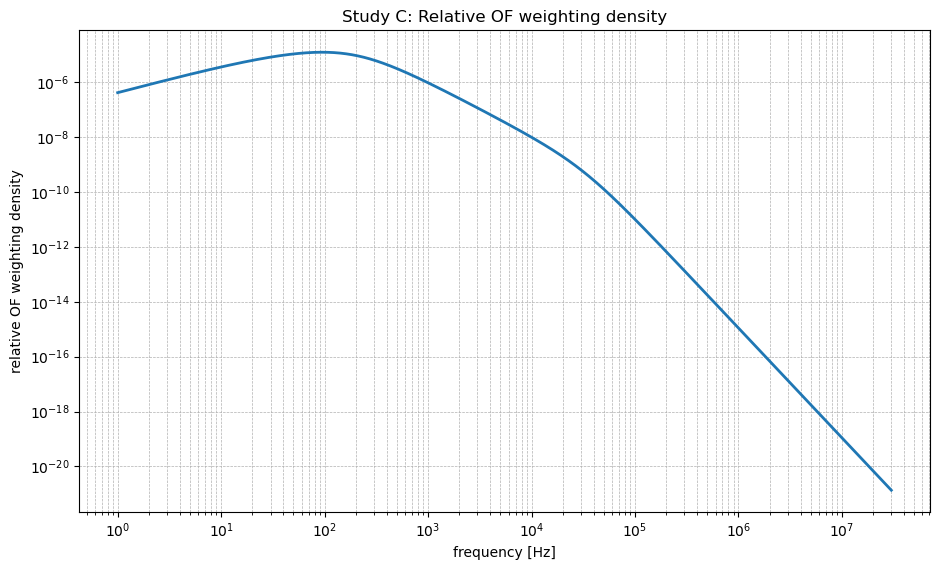

In [16]:
print("Study C weighting density diagnostics:")
print(f"- exact frequency interval used [Hz]: [{study_c_freq[0]:.6g}, {study_c_freq[-1]:.6g}]")
print(f"- finite bins in study_c_W: {np.count_nonzero(np.isfinite(study_c_W))}/{study_c_W.size}")

fig_study_c_weight, ax = plt.subplots(figsize=(9.5, 5.8))
ax.loglog(study_c_freq, study_c_W, linewidth=2.0)
ax.set_title("Study C: Relative OF weighting density")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("relative OF weighting density")
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
fig_study_c_weight.tight_layout()
plt.show()


## Section 3 — Compute cumulative information curve


Cumulative information final value C(f_max) = 1.000000000000


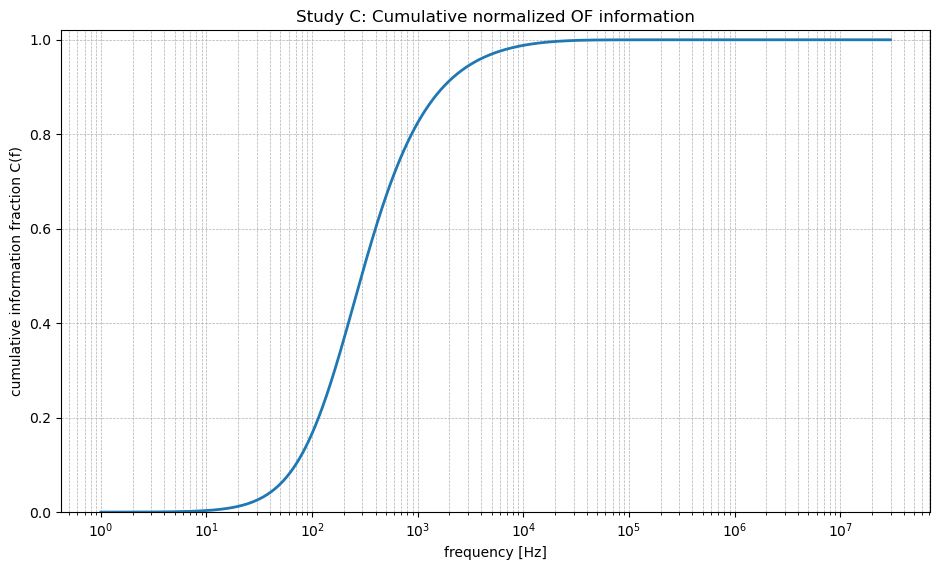

In [17]:
study_c_C = cumulative_trapz_normalized(study_c_freq, study_c_W)

if not np.all(np.diff(study_c_C[np.isfinite(study_c_C)]) >= -1e-12):
    raise RuntimeError("Cumulative information curve is not monotonic within numerical tolerance.")

final_C = float(study_c_C[-1])
print(f"Cumulative information final value C(f_max) = {final_C:.12f}")

fig_study_c_cumulative, ax = plt.subplots(figsize=(9.5, 5.8))
ax.semilogx(study_c_freq, study_c_C, linewidth=2.0)
ax.set_title("Study C: Cumulative normalized OF information")
ax.set_xlabel("frequency [Hz]")
ax.set_ylabel("cumulative information fraction C(f)")
ax.set_ylim(0.0, 1.02)
ax.grid(True, which="both", linestyle="--", linewidth=0.5)
fig_study_c_cumulative.tight_layout()
plt.show()


## Section 4 — Extract effective signal-band landmarks


In [18]:
study_c_levels = np.array([0.10, 0.25, 0.50, 0.75, 0.90])
study_c_freq_landmarks = np.interp(study_c_levels, study_c_C, study_c_freq)

study_c_landmarks_df = pd.DataFrame(
    {
        "cumulative_fraction": study_c_levels,
        "frequency_hz": study_c_freq_landmarks,
    }
)

f10, f25, f50, f75, f90 = study_c_freq_landmarks
central_50_band = (f25, f75)
info_90_band = (f10, f90)

print("Study C landmark frequencies:")
print(study_c_landmarks_df.to_string(index=False))
display(study_c_landmarks_df)

print(f"Band containing central 50% of information (25%-75%): [{central_50_band[0]:.6g}, {central_50_band[1]:.6g}] Hz")
print(f"Interval containing 90% of information (10%-90%): [{info_90_band[0]:.6g}, {info_90_band[1]:.6g}] Hz")


Study C landmark frequencies:
 cumulative_fraction  frequency_hz
                0.10     69.674374
                0.25    138.506644
                0.50    294.194703
                0.75    688.537190
                0.90   1744.366230


,cumulative_fraction,frequency_hz
0,0.10,69.674374
1,0.25,138.506644
2,0.50,294.194703
3,0.75,688.537190
4,0.90,1744.366230


Band containing central 50% of information (25%-75%): [138.507, 688.537] Hz
Interval containing 90% of information (10%-90%): [69.6744, 1744.37] Hz


## Section 5 — Overlay with Study A dominance information

Use AL component PSD decomposition to interpret which source dominates the high-information Study C band.


In [19]:
# Per-bin component fractions on OF-valid band
frac_map = {
    "SQUID": component_psd_overlap["SQUID"] / P_use,
    "Johnson": component_psd_overlap["Johnson"] / P_use,
    "TD": component_psd_overlap["TD"] / P_use,
    "Er": component_psd_overlap["Er"] / P_use,
}

segments = [
    (study_c_freq[0], f10, "fmin-10%"),
    (f10, f25, "10%-25%"),
    (f25, f50, "25%-50%"),
    (f50, f75, "50%-75%"),
    (f75, f90, "75%-90%"),
    (f90, study_c_freq[-1], "90%-fmax"),
]

segment_rows = []
for lo, hi, label in segments:
    m = (study_c_freq >= lo) & (study_c_freq <= hi)
    if np.count_nonzero(m) < 2:
        continue
    med = {k: float(np.nanmedian(v[m])) for k, v in frac_map.items()}
    ranked = sorted(med.items(), key=lambda kv: kv[1], reverse=True)
    dom, dom_frac = ranked[0]
    second, second_frac = ranked[1]
    if dom_frac >= 0.7:
        interp = f"{dom}-dominated"
    elif dom_frac >= 0.5:
        interp = f"{dom}-leading mixed"
    else:
        interp = f"mixed {dom}/{second}"
    segment_rows.append(
        {
            "information_band_segment": label,
            "dominant_noise_source": dom,
            "interpretation": interp,
            "dominant_median_fraction": dom_frac,
        }
    )

study_c_overlay_df = pd.DataFrame(segment_rows)
print("Study C cross-interpretation with Study A dominance:")
print(study_c_overlay_df.to_string(index=False))
display(study_c_overlay_df)

# Optional compact crossover summary in 10-90% info band
pair_defs = [
    ("SQUID vs Johnson", component_psd_overlap["SQUID"], component_psd_overlap["Johnson"]),
    ("SQUID vs TD", component_psd_overlap["SQUID"], component_psd_overlap["TD"]),
    ("Johnson vs TD", component_psd_overlap["Johnson"], component_psd_overlap["TD"]),
]

def find_crossings_local(freq, a, b):
    g = np.log10(a) - np.log10(b)
    out = []
    for i in range(len(g)-1):
        g0, g1 = g[i], g[i+1]
        if not (np.isfinite(g0) and np.isfinite(g1)):
            continue
        if g0 == 0 or g0 * g1 < 0 or g1 == 0:
            x0, x1 = np.log10(freq[i]), np.log10(freq[i+1])
            t = abs(g0) / (abs(g0) + abs(g1)) if (abs(g0) + abs(g1)) > 0 else 0.0
            out.append(float(10**(x0 + t*(x1-x0))))
    return out

cross_rows = []
for pair, a, b in pair_defs:
    xs = [x for x in find_crossings_local(study_c_freq, a, b) if f10 <= x <= f90]
    cross_rows.append({
        "component_pair": pair,
        "crossings_in_10_90_band_hz": ", ".join(f"{x:.4g}" for x in xs) if xs else "none",
    })

study_c_crossover_df = pd.DataFrame(cross_rows)
print("Crossover frequencies within 10%-90% information band:")
print(study_c_crossover_df.to_string(index=False))
display(study_c_crossover_df)


Study C cross-interpretation with Study A dominance:
information_band_segment dominant_noise_source  interpretation  dominant_median_fraction
                fmin-10%                 SQUID SQUID-dominated                  0.890784
                 10%-25%                 SQUID SQUID-dominated                  0.768815
                 25%-50%                 SQUID SQUID-dominated                  0.815123
                 50%-75%                 SQUID SQUID-dominated                  0.902365
                 75%-90%                 SQUID SQUID-dominated                  0.949121
                90%-fmax                 SQUID SQUID-dominated                  0.967351


,information_band_segment,dominant_noise_source,interpretation,dominant_median_fraction
0,fmin-10%,SQUID,SQUID-dominated,0.890784
1,10%-25%,SQUID,SQUID-dominated,0.768815
2,25%-50%,SQUID,SQUID-dominated,0.815123
3,50%-75%,SQUID,SQUID-dominated,0.902365
4,75%-90%,SQUID,SQUID-dominated,0.949121
5,90%-fmax,SQUID,SQUID-dominated,0.967351


Crossover frequencies within 10%-90% information band:
  component_pair crossings_in_10_90_band_hz
SQUID vs Johnson                       none
     SQUID vs TD                       none
   Johnson vs TD                      688.6


,component_pair,crossings_in_10_90_band_hz
0,SQUID vs Johnson,none
1,SQUID vs TD,none
2,Johnson vs TD,688.6


## Section 6 — Study C interpretation cell


In [20]:
# Consolidated Study C interpretation
band10_90_mask = (study_c_freq >= f10) & (study_c_freq <= f90)
med_10_90 = {k: float(np.nanmedian(v[band10_90_mask])) for k, v in frac_map.items()}
rank_10_90 = sorted(med_10_90.items(), key=lambda kv: kv[1], reverse=True)

dom_10_90 = rank_10_90[0][0]
dom_10_90_frac = rank_10_90[0][1]

info_below_f10 = float(np.interp(f10, study_c_freq, study_c_C))
low_freq_comment = (
    "Most OF information avoids the lowest-frequency region."
    if info_below_f10 <= 0.15
    else "A non-negligible OF information fraction remains in the lowest-frequency region."
)

summary_lines = [
    "### Study C Summary (Signal-band weighting)",
    f"- Majority useful OF information is concentrated between {f10:.4g} Hz and {f90:.4g} Hz (10%-90% cumulative band).",
    f"- Central 50% OF information band (25%-75%): {f25:.4g} Hz to {f75:.4g} Hz.",
    f"- Dominant noise source in effective 10%-90% signal band: {dom_10_90} (median fraction={dom_10_90_frac:.3f}).",
    f"- {low_freq_comment}",
    "- Engineering priority should emphasize reducing the dominant component inside the effective signal-information band; reductions far outside that band are expected to have limited effect on reconstruction performance.",
    "- This remains a relative frequency-domain conclusion; final absolute detector resolution is deferred to later OF-noise-trace time-domain validation.",
]

display(Markdown("\n".join(summary_lines)))


### Study C Summary (Signal-band weighting)
- Majority useful OF information is concentrated between 69.67 Hz and 1744 Hz (10%-90% cumulative band).
- Central 50% OF information band (25%-75%): 138.5 Hz to 688.5 Hz.
- Dominant noise source in effective 10%-90% signal band: SQUID (median fraction=0.878).
- Most OF information avoids the lowest-frequency region.
- Engineering priority should emphasize reducing the dominant component inside the effective signal-information band; reductions far outside that band are expected to have limited effect on reconstruction performance.
- This remains a relative frequency-domain conclusion; final absolute detector resolution is deferred to later OF-noise-trace time-domain validation.

## Section 8 — Explicit Limitation Section

- This notebook provides a **frequency-domain relative impact study**.
- It does **not** yet define final detector resolution.
- Later, detector resolution will be evaluated from the **standard deviation of OF amplitudes fitted to noise traces**.
- That later step will validate and connect the present frequency-domain ranking to the time-domain OF estimator.
- No MMC inputs are used here.
- No absolute energy-resolution claim is made here without independent calibration metadata.
- No measured-baseline residual modeling is included yet.
